----
# **<span style="color:darkmagenta">PROYECTO EDA - BANK MARKETING</span>**
----

---
---
## <span style="color:gray">**1. Importación de librerías**</span> 📂

In [2]:
# Tratamiento de datos
import numpy as np
import pandas as pd 

# Visualización de datos
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Configuración de ruta
import sys
sys.path.append('../')

from src.soporte import columnas_df
from src.soporte import graficos_categoricos

---
---
## <span style="color:gray">**2. Carga de datos**</span> 📥

In [3]:
# Utilizamos los datos que hemos guardado tras la limpieza
bank_data_limpio = pd.read_csv("../data/output/bank_data_limpio.csv")
customer_data_limpio = pd.read_csv("../data/output/customer_data_limpio.csv")

In [4]:
# Configuración para mostrar todas las columnas
pd.set_option('display.max_columns', None) 

----
# <span style="color:darkmagenta">**Desarrollo del proyecto - 3**</span> 
----


---
---
## <span style="color:gray">**Integración de datasets**</span> 🔗

In [5]:
df_integrado = pd.merge(bank_data_limpio, customer_data_limpio, on='id', how='left')

# Lo guardamos en un csv
df_integrado.to_csv("../data/output/df_integrado.csv", index=False)

Recordamos la estructura del dataset:

In [6]:
df_integrado.head(3)

,age,job,marital_status,education_level,default,housing_loan,personal_loan,contact_method,campaign_contacts,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,number_employees,subscribed,contact_date,id,contacted_before,income,num_kids_home,num_teens_home,customer_since,num_web_visits_month
0,38,housemaid,married,basic_4y,no,no,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857000,5191,no,2019-08-02,089b39d8-e4d0-461b-87d4-814d71e0e079,no,161770,1,0,2012-04-04,29
1,57,services,married,high_school,no,no,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,3.616521,5191,no,2016-09-14,e9d37224-cb6f-4942-98d7-46672963d097,no,85477,1,1,2012-12-30,7
2,37,services,married,high_school,no,si,no,telephone,1,0,nonexistent,1.1,93.994,-36.4,4.857000,5191,no,2019-02-15,3f9f49b5-e410-4948-bf6e-f9244f04918b,no,147233,1,1,2012-02-02,5


La columna `id` la podemos eliminar ya que solo la necesitábamos para la integración de los dataset

In [7]:
df_integrado = df_integrado.drop('id', axis=1)

In [8]:
columnas_df(df_integrado)

Las columnas del DataFrame que estamos analizando son:


Index(['age', 'job', 'marital_status', 'education_level', 'default',
       'housing_loan', 'personal_loan', 'contact_method', 'campaign_contacts',
       'previous_contacts', 'previous_campaign_outcome',
       'employment_variation_rate', 'consumer_price_index',
       'consumer_confidence_index', 'euribor_3m_rate', 'number_employees',
       'subscribed', 'contact_date', 'contacted_before', 'income',
       'num_kids_home', 'num_teens_home', 'customer_since',
       'num_web_visits_month'],
      dtype='str')

Información básica de las columnas:

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        43000 non-null  int64  
 1   job                        43000 non-null  str    
 2   marital_status             43000 non-null  str    
 3   education_level            43000 non-null  str    
 4   default                    43000 non-null  str    
 5   housing_loan               43000 non-null  str    
 6   personal_loan              43000 non-null  str    
 7   contact_method             43000 non-null  str    
 8   campaign_contacts          43000 non-null  int64  
 9   previous_contacts          43000 non-null  int64  
 10  previous_campaign_outcome  43000 non-null  str    
 11  employment_variation_rate  43000 non-null  float64
 12  consumer_price_index       43000 non-null  float64
 13  consumer_confidence_

,count,mean,std,min,25%,50%,75%,max
age,43000.0,39.74,9.82,17.00,33.00,38.00,46.00,98.00
campaign_contacts,43000.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
previous_contacts,43000.0,0.17,0.50,0.00,0.00,0.00,0.00,7.00
employment_variation_rate,43000.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
consumer_price_index,43000.0,93.57,0.58,92.20,93.08,93.57,93.99,94.77
consumer_confidence_index,43000.0,-40.51,4.64,-50.80,-42.70,-41.80,-36.40,-26.90
euribor_3m_rate,43000.0,3.62,1.54,0.63,1.47,4.08,4.96,5.04
number_employees,43000.0,5166.84,72.34,4964.00,5099.00,5191.00,5228.00,5228.00
income,43000.0,93241.20,50498.32,5841.00,49610.00,93050.50,136744.50,180802.00
num_kids_home,43000.0,1.00,0.82,0.00,0.00,1.00,2.00,2.00



Estadísticos de las variables categóricas:



,count,unique,top,freq
job,43000,12,administrative,10873
marital_status,43000,4,married,25999
education_level,43000,8,university_degree,12722
default,43000,2,no,42997
housing_loan,43000,2,si,22498
personal_loan,43000,2,no,36468
contact_method,43000,2,cellular,27396
previous_campaign_outcome,43000,3,nonexistent,37103
subscribed,43000,2,no,38156
contact_date,43000,1825,2018-02-28,343


In [9]:
cols_fecha = ['contact_date', 'customer_since']
for col in cols_fecha:
    df_integrado[col] = pd.to_datetime(df_integrado[col])

---
---
## <span style="color:gray">**EDA sobre el dataset final**</span> 🧩

### <span style="color:darkgray">**7.1. Análisis univariado**</span>  


### <span style="color:darkgray">Distribución de la edad de los usuarios</span>

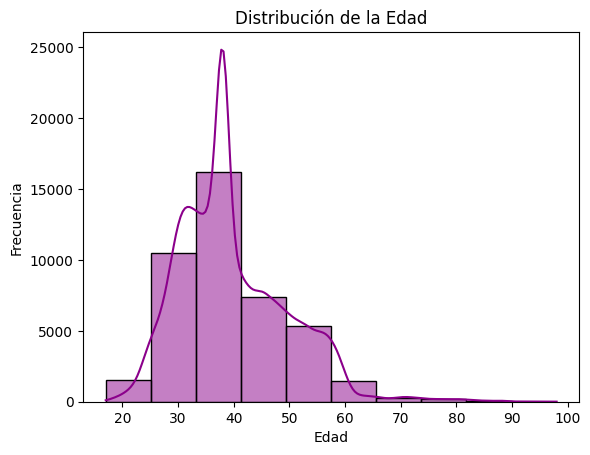

In [10]:
sns.histplot(df_integrado['age'], bins=10, kde=True, color='darkmagenta')
plt.title('Distribución de la Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


### <span style="color:darkgray">Distribución de las columnas categóricas</span>

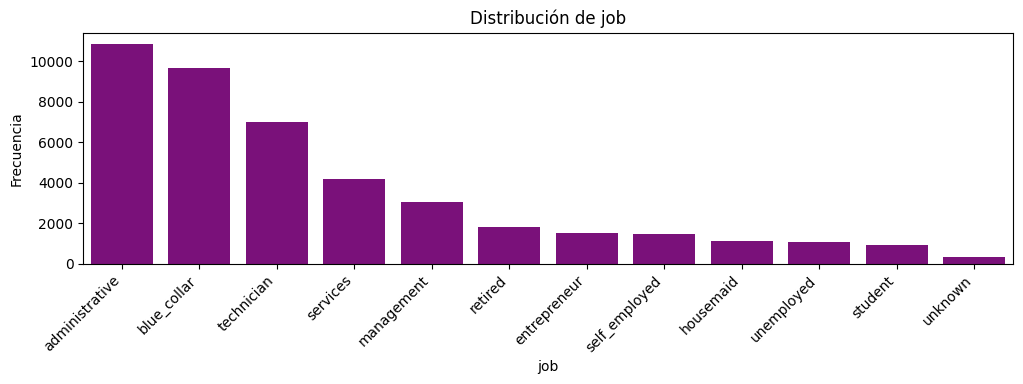

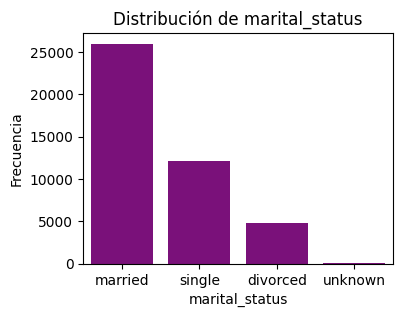

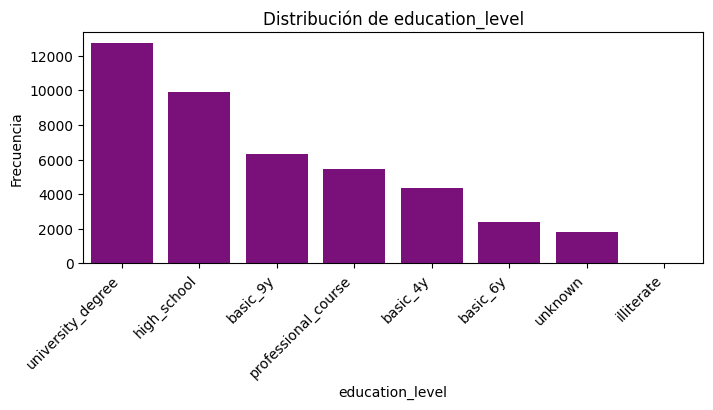

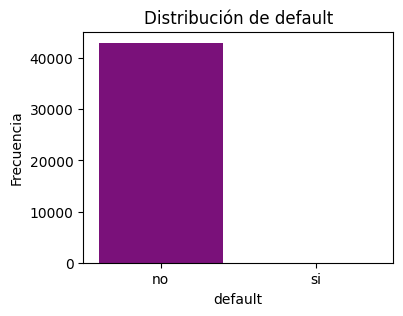

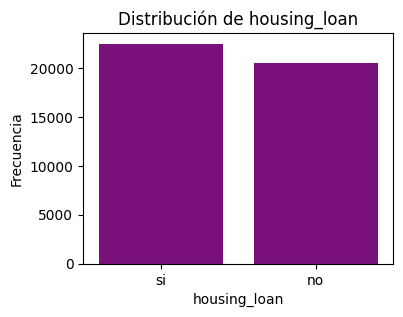

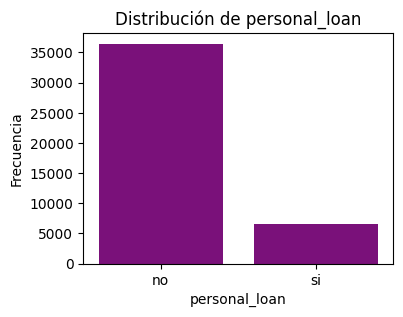

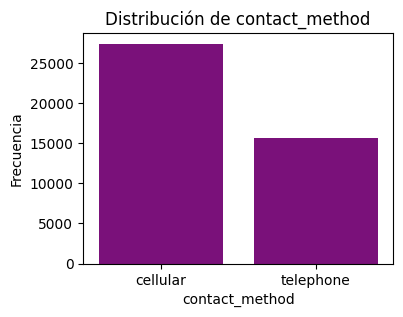

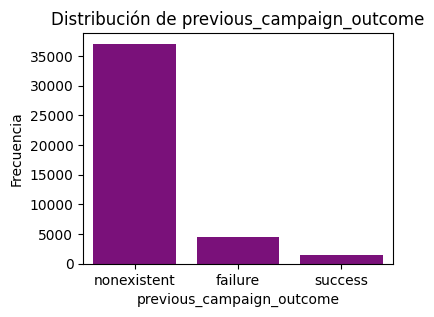

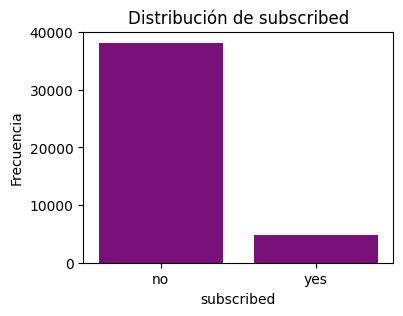

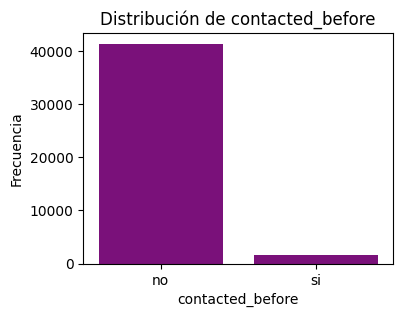

In [11]:
graficos_categoricos(df_integrado, rotar_columnas=['job', 'education_level'])

### <span style="color:darkgray">**7.2. Análisis bivariado**</span>  

### <span style="color:darkgray">Relación entre edad y suscripción</span>  


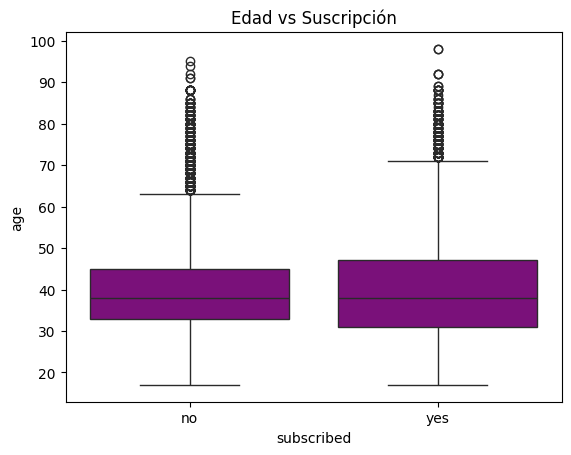

In [12]:
sns.boxplot(x='subscribed', y='age', data=df_integrado, color='darkmagenta')
plt.title("Edad vs Suscripción")
plt.show()

### <span style="color:darkgray">**7.3. Análisis multivariado**</span>  

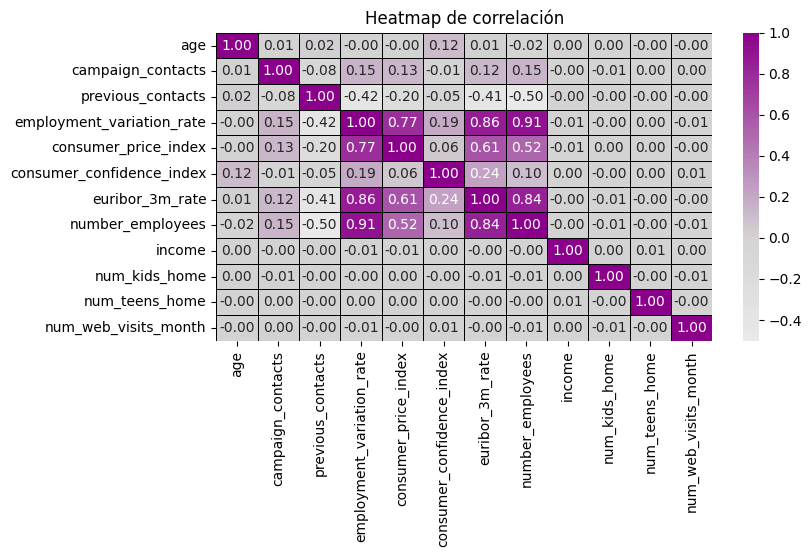

In [18]:
# Seleccionar solo columnas numéricas
col_num = df_integrado.select_dtypes(include='number')

# Matriz de correlación
corr = col_num.corr()

# Mapa de colores personalizado
colors = ["white", "lightgrey", "darkmagenta"]  # baja → alta correlación
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

# Dibujar el heatmap
plt.figure(figsize=(8, 4)) 
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap=cmap, 
    center=0, 
    linewidths=0.5, 
    linecolor='black'
    )
plt.title("Heatmap de correlación")
plt.show()

Eliminación de `number_employees`

La variable number_employees fue inicialmente considerada como posible predictor de suscripción en nuestra campaña bancaria. Sin embargo, tras el análisis exploratorio, se ha decidido eliminarla del dataset por las siguientes razones:

1️⃣ Muy poca variabilidad

Tras limpiar la columna y convertirla a numérica, los valores únicos eran:

[4964, 4992, 5009, 5018, 5024, 5076, 5099, 5176, 5191, 5196, 5228]

Esto muestra un rango extremadamente reducido (~264 unidades).

2️⃣ Separación mínima entre clases

Al agrupar por la variable objetivo subscribed:

No suscriben → 5176
Sí suscriben → 5094

La diferencia media entre ambos grupos es insignificante (~82), lo que indica que no discrimina entre clientes que se suscriben y los que no.

Visualizaciones (boxplots) confirman un solapamiento casi total de la distribución entre clases.

Valores únicos de number_employees: [5191 5228 5196 5176 5099 5076 5018 5024 5009 4992 4964]

Medias de number_employees según suscripción:
subscribed
no     5176.002542
yes    5094.629026
Name: number_employees, dtype: float64


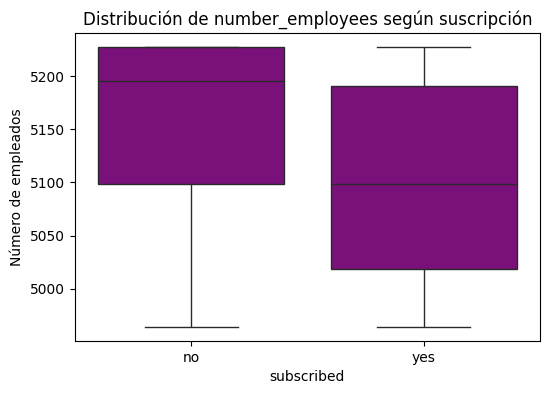

In [30]:
# Mostrar valores únicos
print("Valores únicos de number_employees:", df_integrado['number_employees'].unique())

# Comparar medias por clase
print("\nMedias de number_employees según suscripción:")
print(df_integrado.groupby('subscribed')['number_employees'].mean())

# Boxplot para visualización
plt.figure(figsize=(6,4))
sns.boxplot(x='subscribed', y='number_employees', data=df_integrado, color="DarkMagenta")
plt.title('Distribución de number_employees según suscripción')
plt.ylabel('Número de empleados')
plt.show()

---
---
## <span style="color:gray">**Insights**</span> 💡

---
---
## <span style="color:gray">**Conclusiones finales**</span> 📝